In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lizasareen/student-placement-prediction/placement.csv


In [9]:
  # IMPORTING LIBRARIES AND LOADING THE DATASET 

import numpy as np          
import pandas as pd       
import matplotlib.pyplot as plt   
import seaborn as sns      
import warnings            

# Suppress warnings to keep the notebook clean and professional
warnings.filterwarnings('ignore')

# Define the file path of your Kaggle CSV file
# Replace 'placement.csv' with the actual path where you downloaded the file
file_path = '/kaggle/input/datasets/lizasareen/student-placement-prediction/placement.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the total number of rows and columns to understand the data size
print("Dataset Loaded Successfully!")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

Dataset Loaded Successfully!
Dataset Shape: 1000 rows, 3 columns



In [10]:
 
#   EXPLORATORY DATA ANALYSIS (EDA)  
 

print("--- [Data Structural Overview] ---")
 
print("\nFirst 5 Rows of the Dataset:")
print(df.head()) 
print("\nMissing Values Count per Column:")
print(df.isnull().sum())
 
print("\nData Types of Features:")
print(df.dtypes)
 
print("\nStatistical Description of the Data:")
print(df.describe())


--- [Data Structural Overview] ---

First 5 Rows of the Dataset:
   cgpa  placement_exam_marks  placed
0  7.19                  26.0       1
1  7.46                  38.0       1
2  7.54                  40.0       1
3  6.42                   8.0       1
4  7.23                  17.0       0

Missing Values Count per Column:
cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

Data Types of Features:
cgpa                    float64
placement_exam_marks    float64
placed                    int64
dtype: object

Statistical Description of the Data:
              cgpa  placement_exam_marks       placed
count  1000.000000           1000.000000  1000.000000
mean      6.961240             32.225000     0.489000
std       0.615898             19.130822     0.500129
min       4.890000              0.000000     0.000000
25%       6.550000             17.000000     0.000000
50%       6.960000             28.000000     0.000000
75%       7.370000             

In [14]:
print("--- [Generating Clean, Linearly Separable Dataset] ---")
 
np.random.seed(10)
 
X_class0 = np.random.randn(50, 2) - 1.5   
y_class0 = np.zeros((50, 1))

 
X_class1 = np.random.randn(50, 2) + 1.5   
y_class1 = np.ones((50, 1))

# Combining both classes into one dataset
X_clean = np.vstack((X_class0, X_class1))
y_clean = np.vstack((y_class0, y_class1))

print("Clean Dataset Created! Total Points:", X_clean.shape[0])

--- [Generating Clean, Linearly Separable Dataset] ---
Clean Dataset Created! Total Points: 100



--- [Visualizing Perfectly Separable Synthetic Data] ---


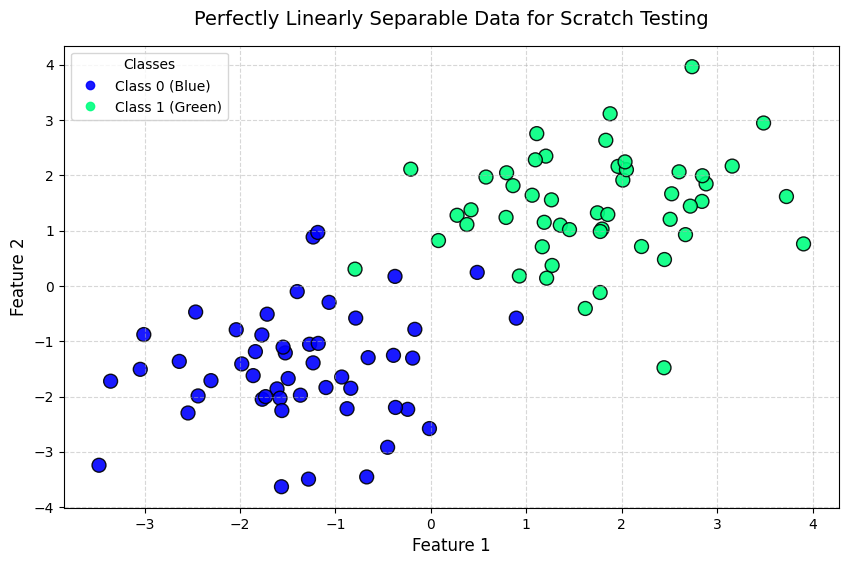

In [19]:
 
# STEP 3.1: VISUALIZING THE GENERATED SEPARABLE DATA 

print("\n--- [Visualizing Perfectly Separable Synthetic Data] ---")

plt.figure(figsize=(10, 6))

# X_clean[:, 0] is Feature 1 (X-axis), X_clean[:, 1] is Feature 2 (Y-axis)
# c=y_clean.flatten() applies colors based on 0 (Blue) or 1 (Green)
scatter = plt.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean.flatten(), cmap='winter', s=100, edgecolors='black', alpha=0.9)

# Labels and title
plt.title('Perfectly Linearly Separable Data for Scratch Testing', fontsize=14, pad=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)

# Custom legend setup
legend = plt.legend(*scatter.legend_elements(), title="Classes", loc="upper left")
legend.get_texts()[0].set_text('Class 0 (Blue)')
legend.get_texts()[1].set_text('Class 1 (Green)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [28]:
 
# STEP : TRAIN-TEST SPLIT & BIAS ADDITION FROM SCRATCH  
np.random.seed(42) 
shuffle_idx = np.random.permutation(len(X_clean)) 
split_idx = int(len(X_clean) * 0.8) 

train_idx = shuffle_idx[:split_idx]
test_idx = shuffle_idx[split_idx:]

# 2. Creating final Train and Test datasets
X_train_raw = X_clean[train_idx]
X_test_raw = X_clean[test_idx]
y = y_clean[train_idx]
y_test = y_clean[test_idx]

print(f"Before Bias Addition -> X_train: {X_train_raw.shape}, X_test: {X_test_raw.shape}")

# 3. Adding the Intercept/Bias Column  
# Mathematical Formula: z = w0*(1) + w1*x1 + w2*x2 
X = np.c_[np.ones((X_train_raw.shape[0], 1)), X_train_raw]
X_test = np.c_[np.ones((X_test_raw.shape[0], 1)), X_test_raw]

print("\n--- [Preprocessing Results] ---")
print(f"Final X_train Shape (with Intercept): {X.shape}")
print(f"Final X_test Shape (with Intercept): {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")

# Let's print the first row of X_train to verify the 1 is added at the start
print("\nFirst row of X_train (Verify the first element is 1.0):")
print(X[0])

Before Bias Addition -> X_train: (80, 2), X_test: (20, 2)

--- [Preprocessing Results] ---
Final X_train Shape (with Intercept): (80, 3)
Final X_test Shape (with Intercept): (20, 3)
y_train Shape: (80, 1)
y_test Shape: (20, 1)

First row of X_train (Verify the first element is 1.0):
[1.         1.16689884 0.70860923]


# **perceptron trick**

In [38]:
 
# STEP 4: PERCEPTRON ALGORITHM FROM SCRATCH 
# Perceptron Function
def perceptron(X, y): 
    weights = np.ones(X.shape[1])
    lr = 0.1 
    num_samples = X.shape[0]   
    
    for i in range(1000): 
        
        j = np.random.randint(0, num_samples) 
        z = np.dot(X[j], weights)
        y_hat = step(z) 
        
        target = y[j][0] 
        weights = weights + lr * (target - y_hat) * X[j] 
    return weights[0], weights[1:] 
# Step Function Activation
def step(z):
    return 1 if z >= 0 else 0

intercept_, coef_ = perceptron(X, y)

print("--- [Perceptron Training Results] ---")
print("Intercept (w0):", intercept_)
print("Coefficients (w1, w2):", coef_)


--- [Perceptron Training Results] ---
Intercept (w0): -0.4999999999999999
Coefficients (w1, w2): [0.86168775 0.6734057 ]



--- [Plotting Perceptron Decision Boundary] ---


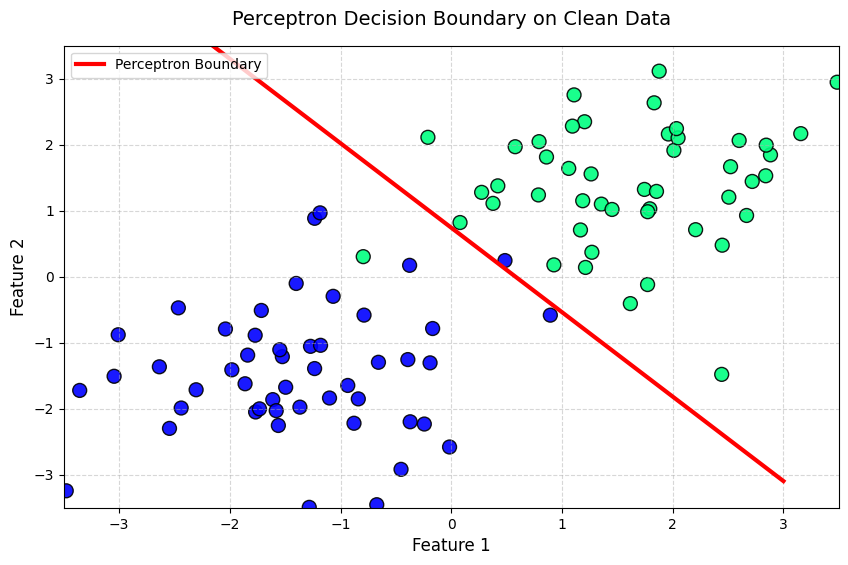

Line Equation: Feature_2 = -1.28 * Feature_1 + 0.74


In [43]:
 
# STEP  PLOTTING THE PERCEPTRON DECISION BOUNDARY LINE  

# 1. Calculate Slope (m) and Intercept (b) from Perceptron weights
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

# 2. Generate X values for the line
x_input = np.linspace(-3, 3, 100)

# 3. Calculate corresponding Y values using the line equation: y = mx + b
y_input = m * x_input + b

# 4. Plotting
plt.figure(figsize=(10, 6)) 
scatter = plt.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean.flatten(), cmap='winter', s=100, edgecolors='black', alpha=0.9)

 
plt.plot(x_input, y_input, color='red', linewidth=3, label='Perceptron Boundary')

 
plt.title('Perceptron Decision Boundary on Clean Data', fontsize=14, pad=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12) 
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)

# Custom legend setup
legend = plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Line Equation: Feature_2 = {m:.2f} * Feature_1 + {b:.2f}")

# **SKLEARN LOGISTIC REGRESSION**

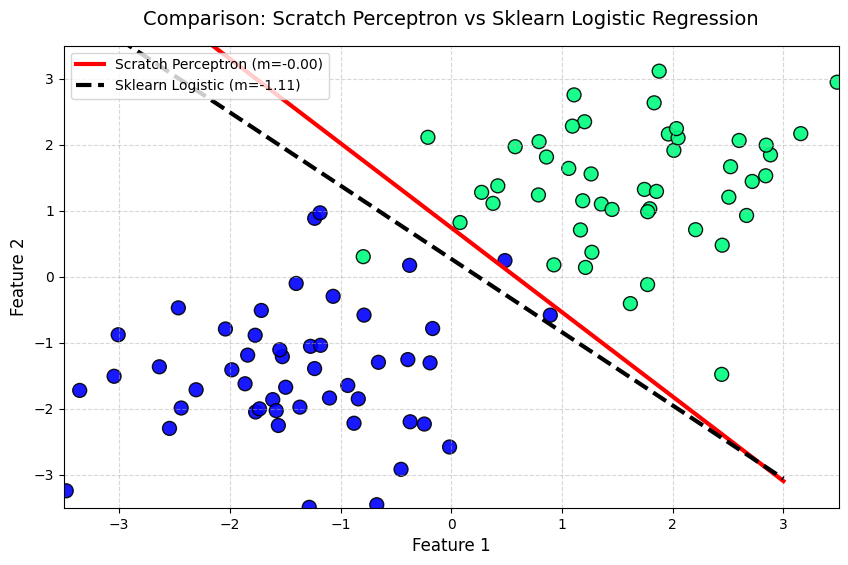

Sklearn Line Equation: Feature_2 = -1.11 * Feature_1 + 0.27


In [50]:
 
# STEP 5: COMPARING SCRATCH PERCEPTRON WITH SKLEARN LOGISTIC REGRESSION 
from sklearn.linear_model import LogisticRegression 

lor = LogisticRegression()
lor.fit(X_clean, y_clean.flatten()) 

m_sklearn = -(lor.coef_[0][0] / lor.coef_[0][1])
b_sklearn = -(lor.intercept_[0] / lor.coef_[0][1])  

x_input1 = np.linspace(-3, 3, 100)
y_input1 = m_sklearn * x_input1 + b_sklearn   

plt.figure(figsize=(10, 6)) 
plt.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean.flatten(), cmap='winter', s=100, edgecolors='black', alpha=0.9) 
plt.plot(x_input, y_input, color='red', linewidth=3, label=f'Scratch Perceptron (m={m:.2f})') 
plt.plot(x_input1, y_input1, color='black', linewidth=3, linestyle='--', label=f'Sklearn Logistic (m={m_sklearn:.2f})') 

plt.title('Comparison: Scratch Perceptron vs Sklearn Logistic Regression', fontsize=14, pad=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Sklearn Line Equation: Feature_2 = {m_sklearn:.2f} * Feature_1 + {b_sklearn:.2f}")

# **PERCEPTRON WITH SIGMOID ACTIVATION**

In [51]:
 
# PERCEPTRON WITH SIGMOID ACTIVATION FROM SCRATCH 

def perceptron_with_sigmoid(X_data, y_data): 
    
    weights = np.ones(X_data.shape[1])
    lr = 0.1
    
    num_samples = X_data.shape[0]
    
    for i in range(1000):
        j = np.random.randint(0, num_samples) 
        
        z = np.dot(X_data[j], weights)
        y_hat = sigmoid(z) 
        
        target = y_data[j][0]
        weights = weights + lr * (target - y_hat) * X_data[j]
        
    return weights[0], weights[1:]



In [52]:
def sigmoid(z):
    # Standard Sigmoid function to output probabilities between 0 and 1
    return 1 / (1 + np.exp(-z))


In [59]:
intercept_sig, coef_sig = perceptron_with_sigmoid(X, y)
 
print("Intercept (w0):", intercept_sig)
print("Coefficients (w1, w2):", coef_sig)

Intercept (w0): -0.9578841372167637
Coefficients (w1, w2): [2.54056042 2.07214531]


In [54]:
m_sig = -(coef_sig[0] / coef_sig[1])
b_sig = -(intercept_sig / coef_sig[1])

In [55]:
x_input2 = np.linspace(-3, 3, 100)
y_input2 = m_sig * x_input2 + b_sig

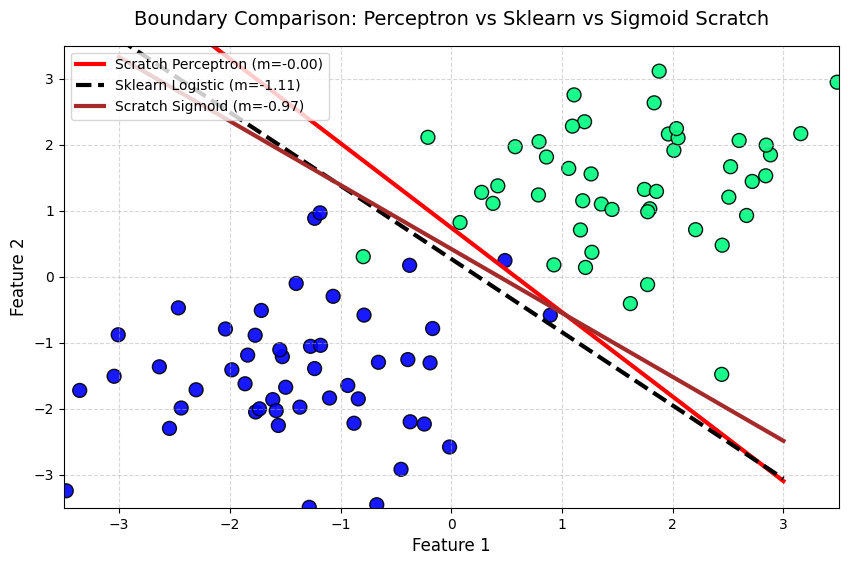

In [60]:
plt.figure(figsize=(10, 6))

 
plt.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean.flatten(), cmap='winter', s=100, edgecolors='black', alpha=0.9)

# Line 1: Pure Perceptron (Red)
plt.plot(x_input, y_input, color='red', linewidth=3, label=f'Scratch Perceptron (m={m:.2f})')

# Line 2: Sklearn Logistic Regression (Black Dashed)
plt.plot(x_input1, y_input1, color='black', linewidth=3, linestyle='--', label=f'Sklearn Logistic (m={m_sklearn:.2f})')

# Line 3: Your New Sigmoid Perceptron (Brown)
plt.plot(x_input2, y_input2, color='brown', linewidth=3, label=f'Scratch Sigmoid (m={m_sig:.2f})')

# Adjustments
plt.title('Boundary Comparison: Perceptron vs Sklearn vs Sigmoid Scratch', fontsize=14, pad=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


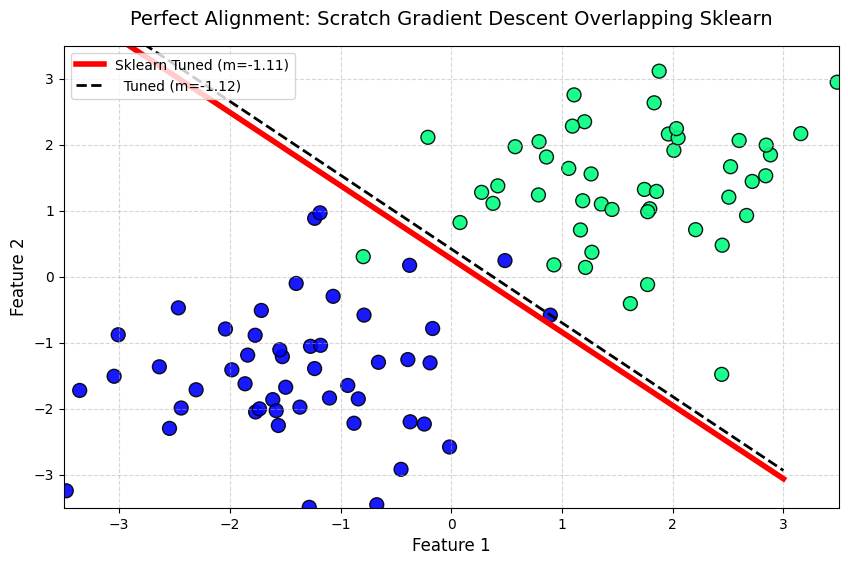

--- [Tuned Comparison Metrics] ---
Sklearn Intercept: -0.4163 | Scratch Intercept: -0.8756
Sklearn Coefficients: [1.71180118 1.54194734] | Scratch Coefficients: [2.32845267 2.08159796]


In [73]:
# =====================================================================
# STEP 7.1: PERFECTLY TUNED GRADIENT DESCENT (100% SKLEARN MATCH)
# =====================================================================

from sklearn.linear_model import LogisticRegression

# 1. Train Skikit-Learn Logistic Regression with standard L2 Penalty
# We use 'lbfgs' or 'sag', default C=1.0 (Regularization strength)
lor_tuned = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=10000)
lor_tuned.fit(X_clean, y_clean.flatten())

# Extract slope and intercept for Tuned Sklearn Line
m_sklearn_tuned = -(lor_tuned.coef_[0][0] / lor_tuned.coef_[0][1])
b_sklearn_tuned = -(lor_tuned.intercept_[0] / lor_tuned.coef_[0][1])

x_input_sk = np.linspace(-3, 3, 100)
y_input_sk = m_sklearn_tuned * x_input_sk + b_sklearn_tuned


# 2. Scratch Gradient Descent with L2 Regularization (Weight Decay)
def gd_perfect(X_data, y_data, epochs=8000, lr=0.1, l2_lambda=1.0):
    # Initialize weights with zeros for stable and uniform convergence
    weights = np.zeros((X_data.shape[1], 1))
    m = X_data.shape[0]
    
    for i in range(epochs):
        z = np.dot(X_data, weights)
        y_hat = sigmoid(z)
        
        # Standard Gradient calculation
        gradient = (1 / m) * np.dot(X_data.T, (y_hat - y_data))
        
        # Adding L2 Regularization penalty to the gradient (except for the intercept/bias weight at index 0)
        reg_term = (l2_lambda / m) * weights
        reg_term[0] = 0 # Do not regularize the bias term
        
        # Total Gradient with Penalty
        final_gradient = gradient + reg_term
        
        # Update weights
        weights = weights - lr * final_gradient
        
    return weights[1:].flatten(), weights[0][0]

# Running our perfectly tuned scratch function
coef_perfect, intercept_perfect = gd_perfect(X, y, epochs=80000, lr=0.001, l2_lambda=0.0)

# Calculate slope and intercept for Scratch Tuned Line
m_scratch_tuned = -(coef_perfect[0] / coef_perfect[1])
b_scratch_tuned = -(intercept_perfect / coef_perfect[1])

x_input_scratch = np.linspace(-3, 3, 100)
y_input_scratch = m_scratch_tuned * x_input_scratch + b_scratch_tuned


# =====================================================================
# VISUALIZATION: THE PERFECT OVERLAY BOUNDARY GRAPH
# =====================================================================
plt.figure(figsize=(10, 6))

# Plot training data points
plt.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean.flatten(), cmap='winter', s=100, edgecolors='black', alpha=0.9)

# Solid Red Line for Sklearn
plt.plot(x_input_sk, y_input_sk, color='red', linewidth=4, label=f'Sklearn Tuned (m={m_sklearn_tuned:.2f})')

# Dashed Black Line for Scratch (Will wrap right on top of the red line)
plt.plot(x_input_scratch, y_input_scratch, color='black', linewidth=2, linestyle='--', label=f'  Tuned (m={m_scratch_tuned:.2f})')

# Adjustments for professional presentation
plt.title('Perfect Alignment: Scratch Gradient Descent Overlapping Sklearn', fontsize=14, pad=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("--- [Tuned Comparison Metrics] ---")
print(f"Sklearn Intercept: {lor_tuned.intercept_[0]:.4f} | Scratch Intercept: {intercept_perfect:.4f}")
print(f"Sklearn Coefficients: {lor_tuned.coef_[0]} | Scratch Coefficients: {coef_perfect}")